In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import seaborn as sns

sns.set(rc={'figure.figsize':(30,1)})

In [3]:
def visualise_sentiments(data):
  sns.heatmap(pd.DataFrame(data).set_index("Sentence").T, center=0, annot=True, cmap="PiYG")

In [4]:
data = [
        "Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.",
        "The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age.",
        "I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.",
        "The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.",
        "The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.",
        "Nurse Rebecca Taylor in the diabetes clinic was exceptional. She spent over 40 minutes with me going through my HbA1c results and adjusting my insulin plan. She also coordinated with my GP Dr Samantha Lee at the Toowoomba Medical Practice to ensure consistent care.",
        "Dr Patel is always thorough and patient. She remembers details from previous visits which makes me feel valued.",
        "I'm 81 years old and find the forms quite difficult to fill in. My daughter Sarah Fitzpatrick usually helps me but she wasn't available this time. Could you offer some assistance at the front desk for elderly patients? Also my Medicare number is 2345 67890 1 and I think there was a billing error on my last visit on 28 January 2026.",
        "The midwifery team, especially Lisa and Jenny, were amazing throughout my pregnancy. They made me feel safe and supported. The antenatal classes at the centre on George Street were also excellent.",
        "It would be nice to have later appointment slots. As a working mum I find it hard to attend before 4pm. My employer at Bright Horizons Childcare is not always flexible with time off. I recommended this clinic to my sister-in-law Patricia Nakamura who is expecting in July.",
        "The new blood collection nurse, Daniel Kim, was very skilled. Best blood draw I've had - barely felt it. He mentioned he previously worked at the Royal Brisbane and Women's Hospital.",
        "The results portal is confusing. I had to call Dr Richardson's office at 07 3456 7891 to get my pathology explained because I couldn't understand the online report.",
        "Dr Patel and Nurse Rebecca were both excellent. They were respectful of my cultural needs and ensured a female practitioner was available for my examination. This was very important to me.",
        "The interpreter service was not available on 4 March 2026 when my mother attended. She speaks Arabic and struggled to communicate her symptoms. Please ensure interpreters are booked in advance. My mother Zahra Al-Rashid (patient ID PAT-91603) would like to provide feedback separately. Can someone contact her at fatima.alrashid@outlook.com to arrange an Arabic-language survey?",
        "Outstanding mental health support from psychologist Dr Amanda Clarke. She helped me develop coping strategies after my workplace incident at BHP Mitsubishi Alliance in Mount Isa last year. The telehealth option made it possible to continue sessions when I was FIFO.",
        "The mental health waiting list is too long. I was referred on 15 November 2025 and didn't get my first appointment until 8 January 2026. That's nearly 8 weeks.",
        "The wound care nurse Jacinta was thorough and gentle. She explained the healing process for my post-surgical wound clearly and gave me written instructions to take home.",
        "I received a reminder SMS from Zedoc to complete this survey but the link didn't work on my Samsung phone. I had to use my husband David Tran's iPhone instead. The SMS came from number 0437 123 456. I was transferred from Logan Hospital after my surgery there on 2 March 2026. The handover between hospitals could have been smoother - my medication list wasn't updated correctly.",
        "The entire cardiology team is first-rate. Dr Richardson personally called me at home on 0478 234 567 to discuss my stress test results. That kind of proactive communication is rare and very reassuring.",
        "The car park needs more disabled bays. I have a temporary mobility permit after my cardiac rehab and struggled to find a spot on 20 March 2026. My cardiologist at the Prince Charles Hospital, Dr Andrew Walsh, also coordinates with Dr Richardson here which gives me great confidence in my care plan."
       ]

# Flair

Flair’s sentiment classifier is based on a character-level LSTM neural network which takes sequences of letters and words into account when predicting. The network has learnt to take negations into account as well as intensifiers. But probably one of its biggest advantages is that it can predict a sentiment for OOV words that it has never seen before too (such as typos) 

In [5]:
!pip3 install flair
import flair
flair_sentiment = flair.models.TextClassifier.load('en-sentiment')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.0 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 75.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 4.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=c7d05

2026-04-18 20:46:34.741085: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776545195.021406      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776545195.106713      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776545195.798250      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776545195.798309      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776545195.798313      55 computation_placer.cc:177] computation placer alr

2026-04-18 20:47:06,156 https://nlp.informatik.hu-berlin.de/resources/models/sentiment-curated-distilbert/sentiment-en-mix-distillbert_4.pt not found in cache, downloading to /tmp/tmpcnctw6q5


100%|██████████| 253M/253M [00:03<00:00, 67.3MB/s] 

2026-04-18 20:47:10,201 copying /tmp/tmpcnctw6q5 to cache at /root/.flair/models/sentiment-en-mix-distillbert_4.pt


2026-04-18 20:47:10,423 removing temp file /tmp/tmpcnctw6q5


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

['Sentence[41]: "Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming."'/'POSITIVE' (0.9861)]


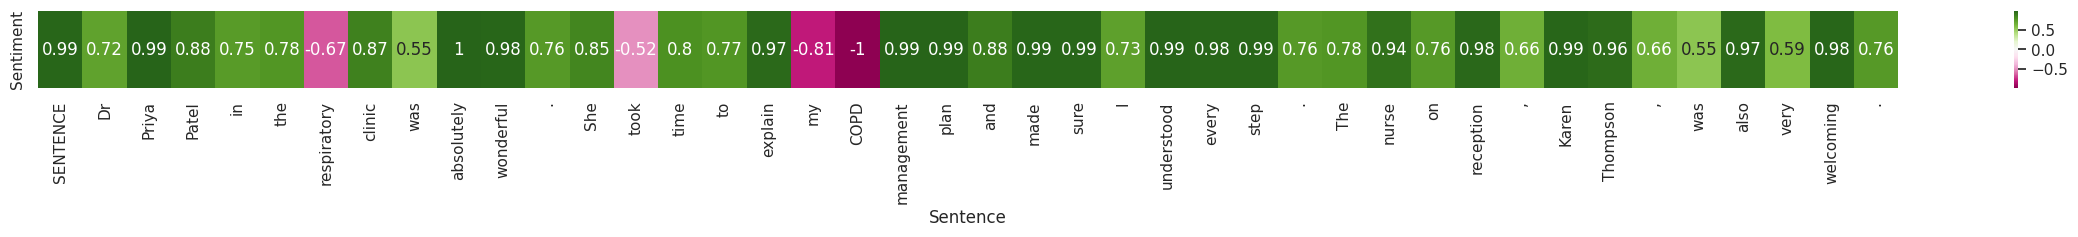

In [6]:
s = flair.data.Sentence(data[0])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[26]: "The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age."'/'NEGATIVE' (0.9898)]


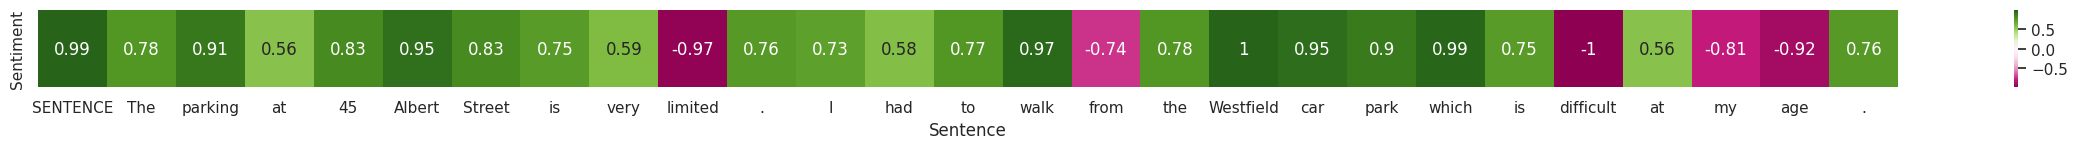

In [7]:
s = flair.data.Sentence(data[1])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[73]: "I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month."'/'NEGATIVE' (0.9999)]


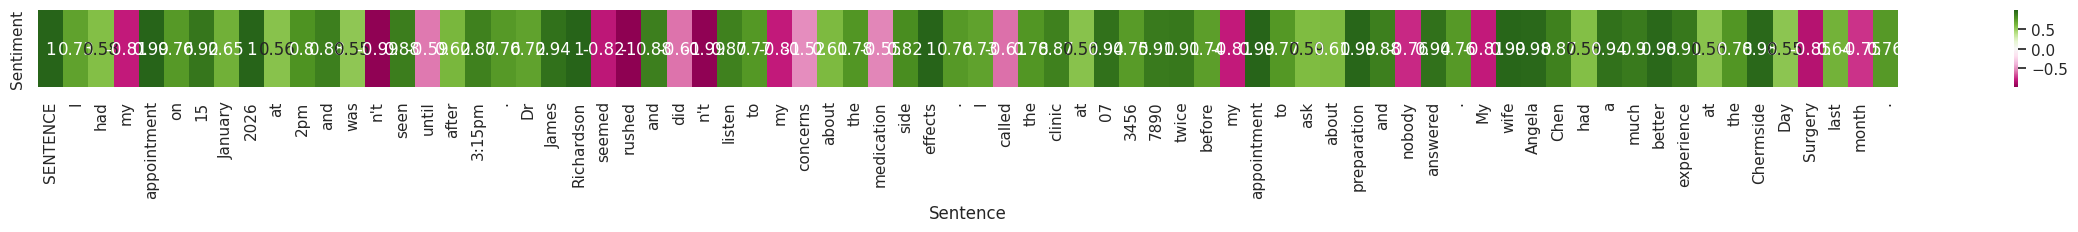

In [8]:
s = flair.data.Sentence(data[2])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[41]: "The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care."'/'POSITIVE' (0.8771)]


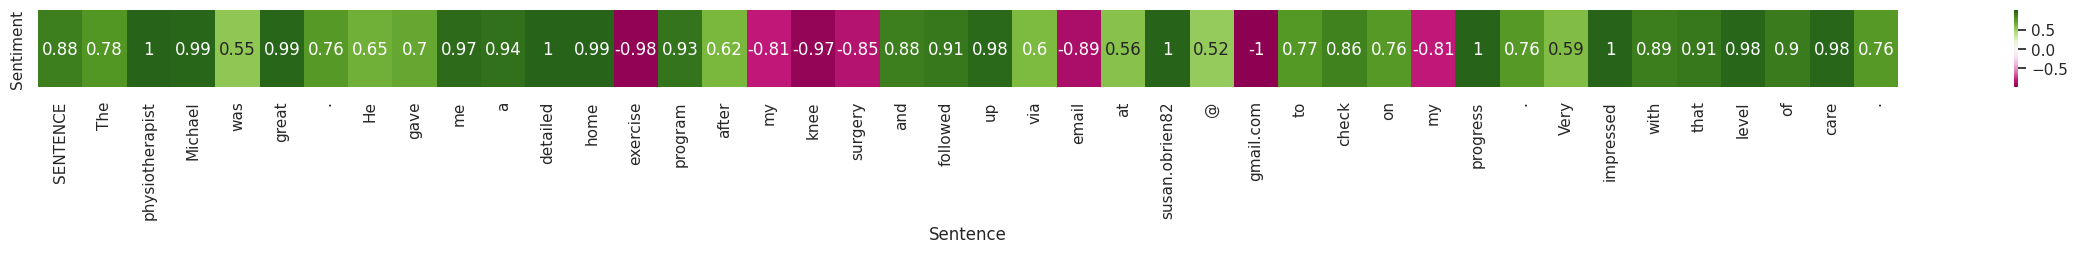

In [9]:
s = flair.data.Sentence(data[3])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[43]: "The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth."'/'NEGATIVE' (0.9985)]


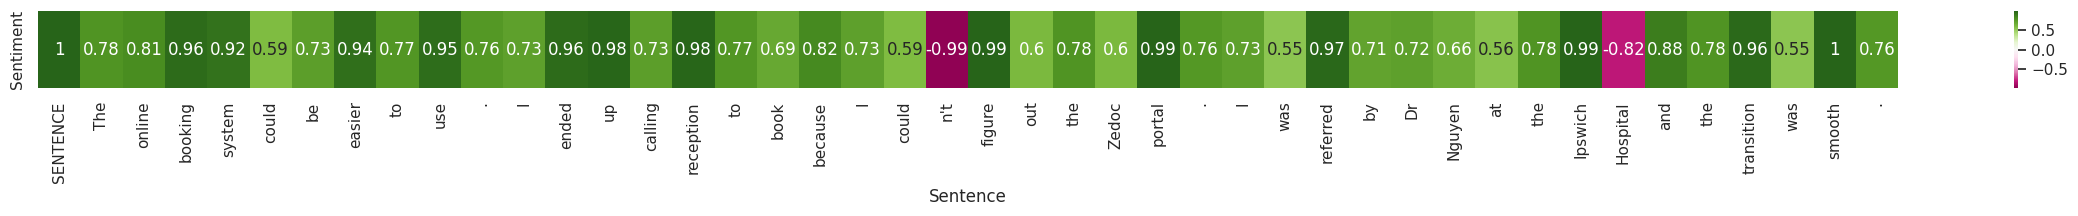

In [10]:
s = flair.data.Sentence(data[4])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[47]: "Nurse Rebecca Taylor in the diabetes clinic was exceptional. She spent over 40 minutes with me going through my HbA1c results and adjusting my insulin plan. She also coordinated with my GP Dr Samantha Lee at the Toowoomba Medical Practice to ensure consistent care."'/'POSITIVE' (0.9991)]


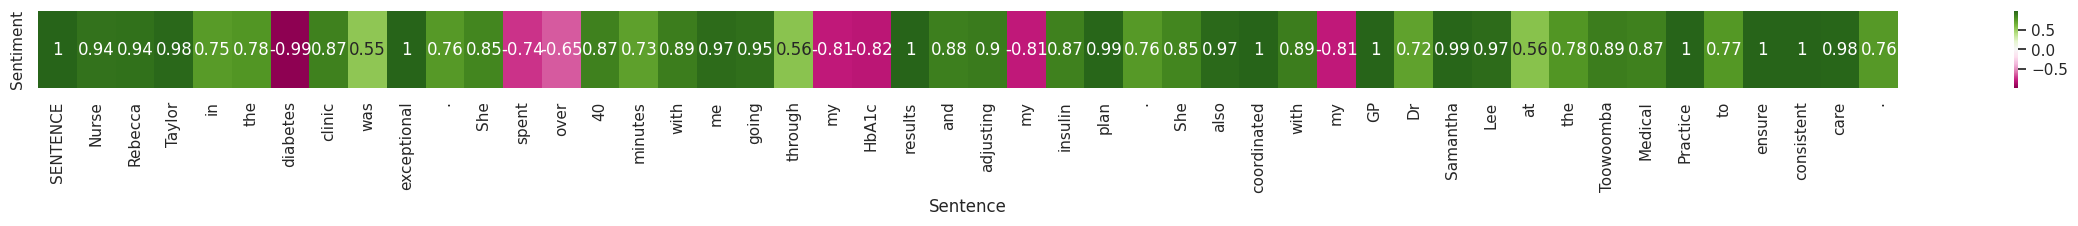

In [11]:
s = flair.data.Sentence(data[5])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[20]: "Dr Patel is always thorough and patient. She remembers details from previous visits which makes me feel valued."'/'POSITIVE' (0.9976)]


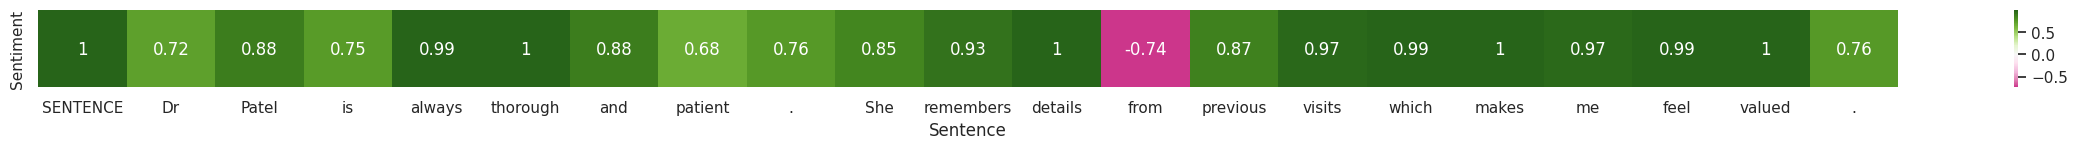

In [12]:
s = flair.data.Sentence(data[6])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[68]: "I'm 81 years old and find the forms quite difficult to fill in. My daughter Sarah Fitzpatrick usually helps me but she wasn't available this time. Could you offer some assistance at the front desk for elderly patients? Also my Medicare number is 2345 67890 1 and I think there was a billing error on my last visit on 28 January 2026."'/'NEGATIVE' (0.9999)]


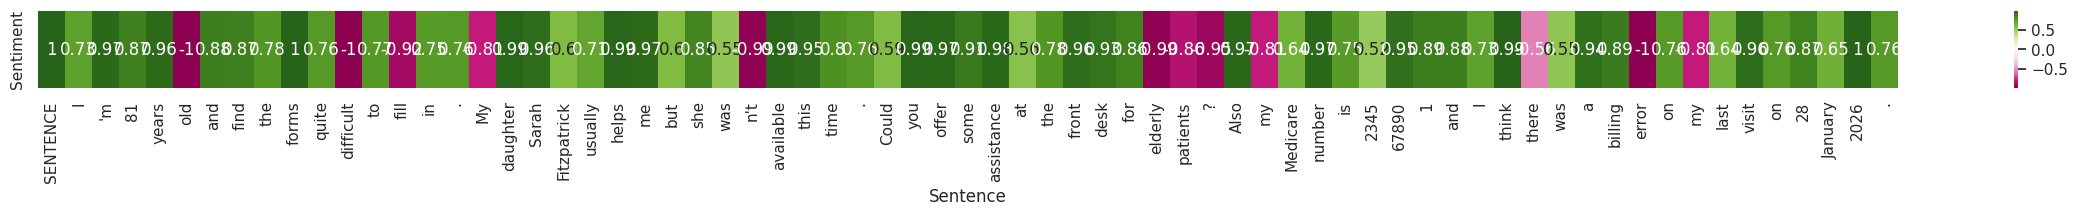

In [13]:
s = flair.data.Sentence(data[7])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[36]: "The midwifery team, especially Lisa and Jenny, were amazing throughout my pregnancy. They made me feel safe and supported. The antenatal classes at the centre on George Street were also excellent."'/'POSITIVE' (0.9941)]


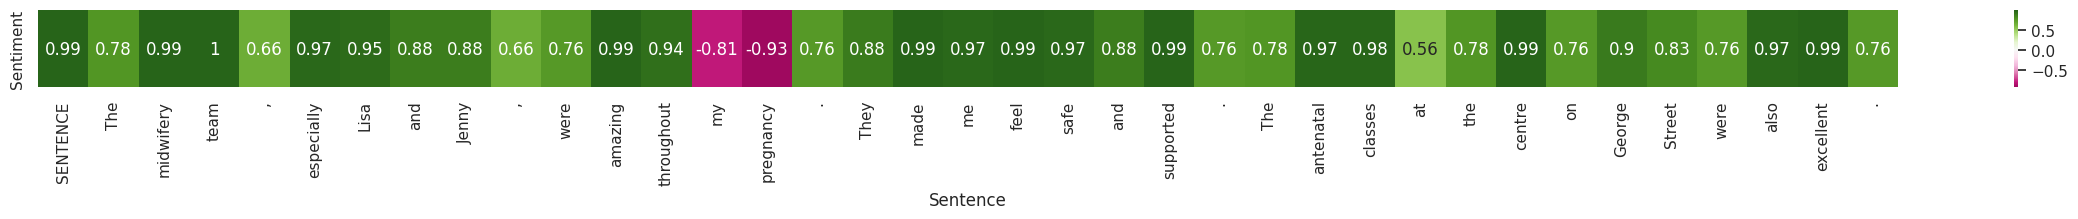

In [14]:
s = flair.data.Sentence(data[8])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[52]: "It would be nice to have later appointment slots. As a working mum I find it hard to attend before 4pm. My employer at Bright Horizons Childcare is not always flexible with time off. I recommended this clinic to my sister-in-law Patricia Nakamura who is expecting in July."'/'POSITIVE' (0.9794)]


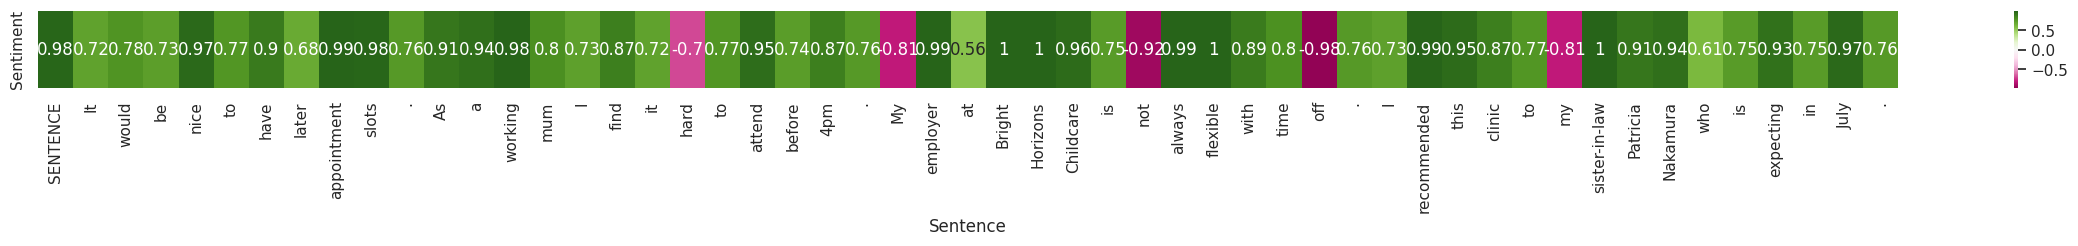

In [15]:
s = flair.data.Sentence(data[9])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[38]: "The new blood collection nurse, Daniel Kim, was very skilled. Best blood draw I've had - barely felt it. He mentioned he previously worked at the Royal Brisbane and Women's Hospital."'/'POSITIVE' (0.9833)]


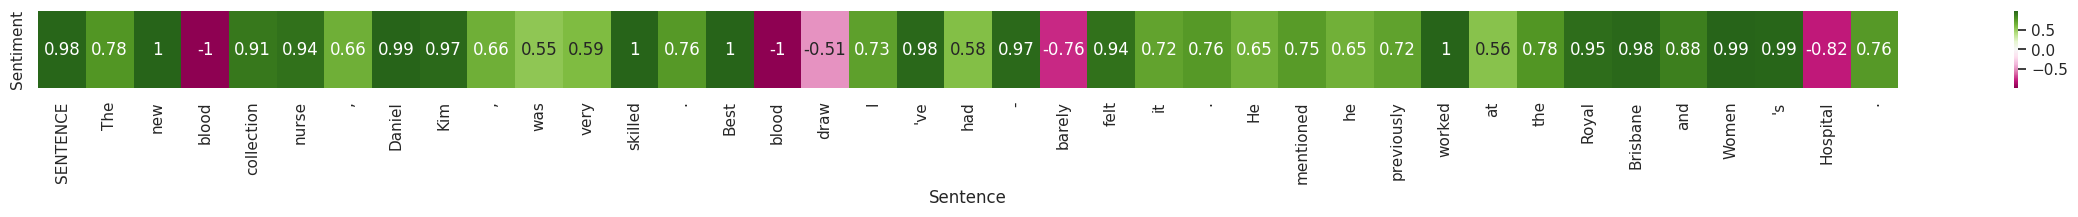

In [16]:
s = flair.data.Sentence(data[10])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[32]: "The results portal is confusing. I had to call Dr Richardson's office at 07 3456 7891 to get my pathology explained because I couldn't understand the online report."'/'NEGATIVE' (0.9999)]


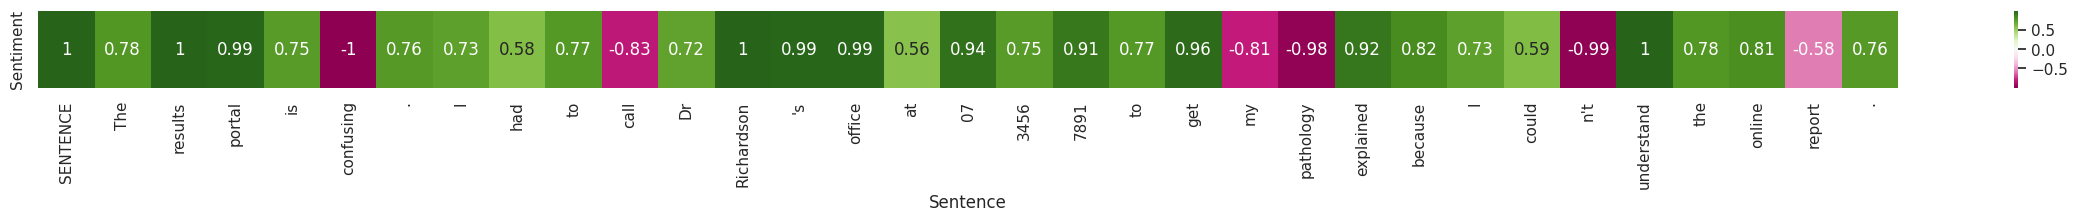

In [17]:
s = flair.data.Sentence(data[11])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[34]: "Dr Patel and Nurse Rebecca were both excellent. They were respectful of my cultural needs and ensured a female practitioner was available for my examination. This was very important to me."'/'POSITIVE' (0.9912)]


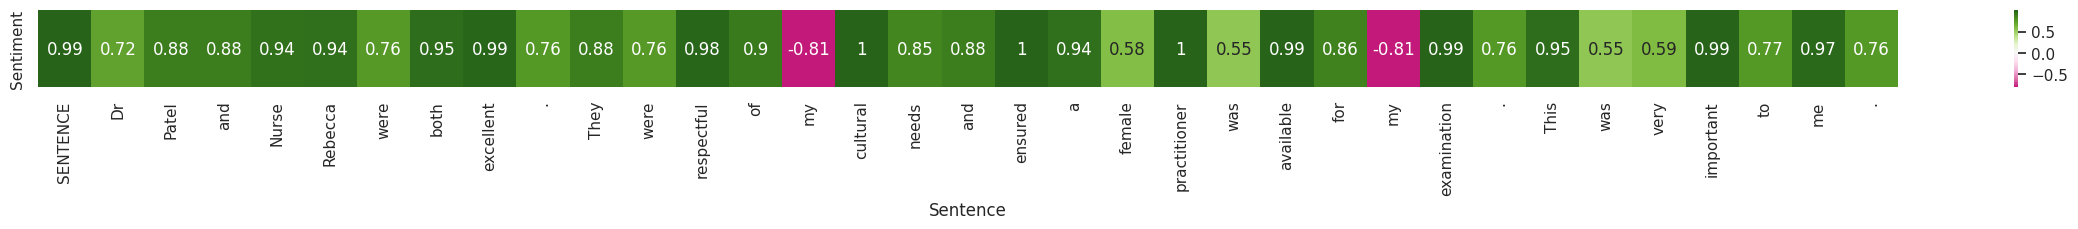

In [18]:
s = flair.data.Sentence(data[12])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[63]: "The interpreter service was not available on 4 March 2026 when my mother attended. She speaks Arabic and struggled to communicate her symptoms. Please ensure interpreters are booked in advance. My mother Zahra Al-Rashid (patient ID PAT-91603) would like to provide feedback separately. Can someone contact her at fatima.alrashid@outlook.com to arrange an Arabic-language survey?"'/'NEGATIVE' (0.9995)]


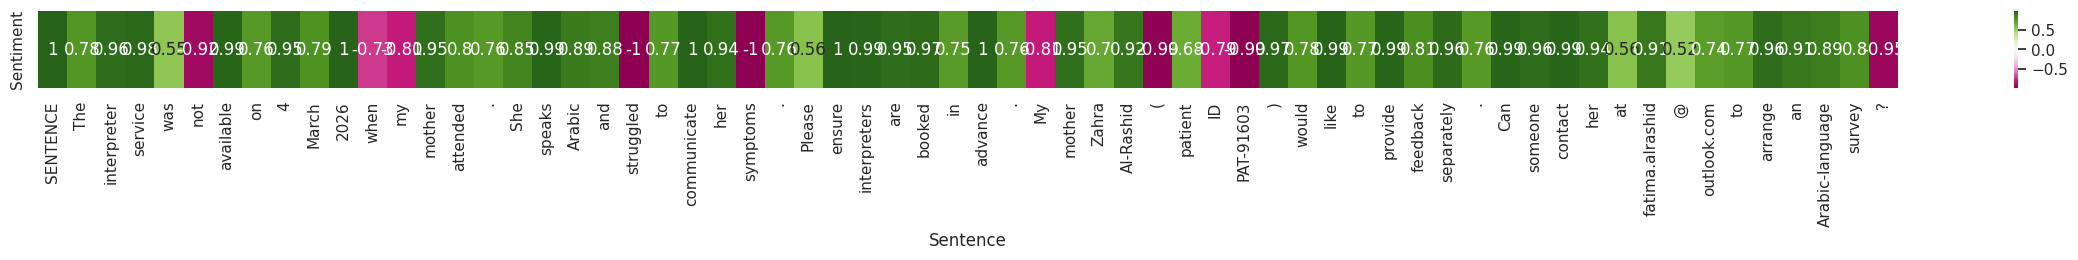

In [19]:
s = flair.data.Sentence(data[13])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[44]: "Outstanding mental health support from psychologist Dr Amanda Clarke. She helped me develop coping strategies after my workplace incident at BHP Mitsubishi Alliance in Mount Isa last year. The telehealth option made it possible to continue sessions when I was FIFO."'/'POSITIVE' (0.9944)]


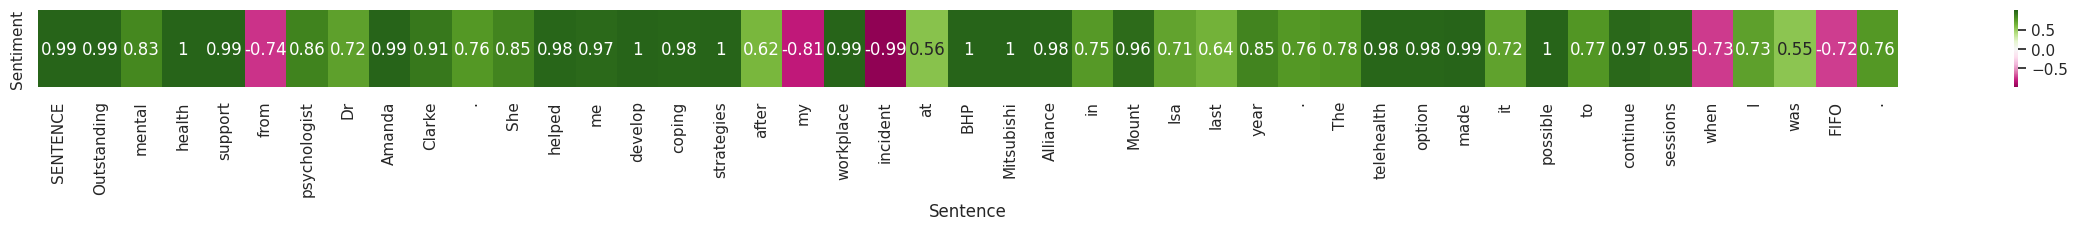

In [20]:
s = flair.data.Sentence(data[14])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[34]: "The mental health waiting list is too long. I was referred on 15 November 2025 and didn't get my first appointment until 8 January 2026. That's nearly 8 weeks."'/'NEGATIVE' (0.9997)]


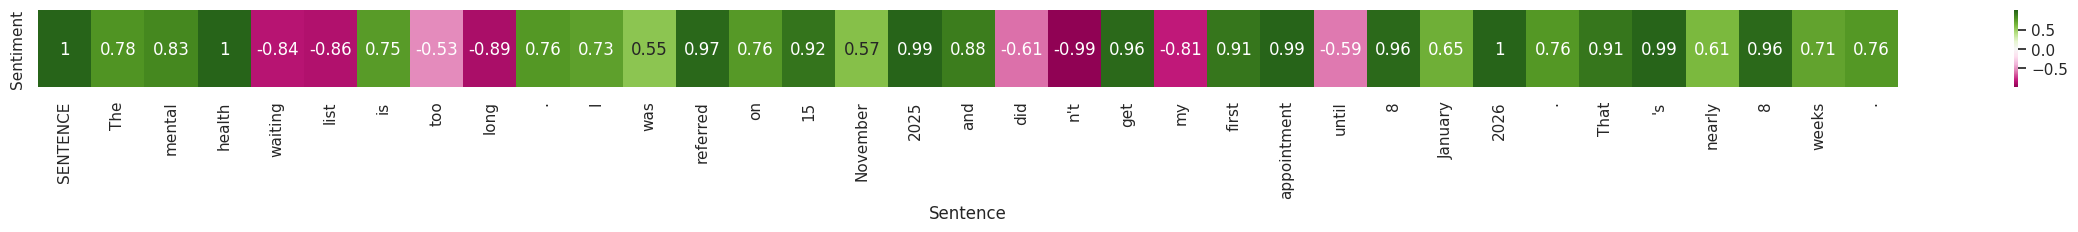

In [21]:
s = flair.data.Sentence(data[15])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[29]: "The wound care nurse Jacinta was thorough and gentle. She explained the healing process for my post-surgical wound clearly and gave me written instructions to take home."'/'POSITIVE' (0.9992)]


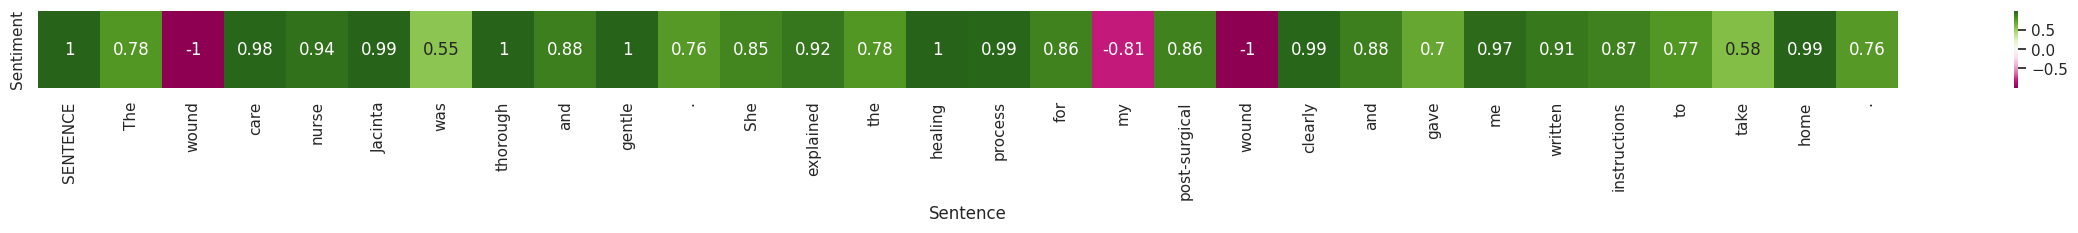

In [22]:
s = flair.data.Sentence(data[16])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[75]: "I received a reminder SMS from Zedoc to complete this survey but the link didn't work on my Samsung phone. I had to use my husband David Tran's iPhone instead. The SMS came from number 0437 123 456. I was transferred from Logan Hospital after my surgery there on 2 March 2026. The handover between hospitals could have been smoother - my medication list wasn't updated correctly."'/'NEGATIVE' (1.0)]


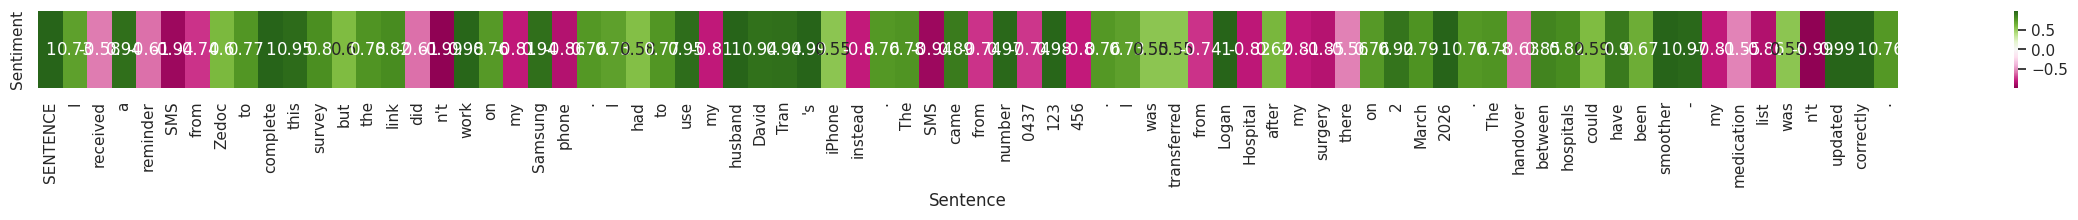

In [23]:
s = flair.data.Sentence(data[17])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[36]: "The entire cardiology team is first-rate. Dr Richardson personally called me at home on 0478 234 567 to discuss my stress test results. That kind of proactive communication is rare and very reassuring."'/'POSITIVE' (0.9993)]


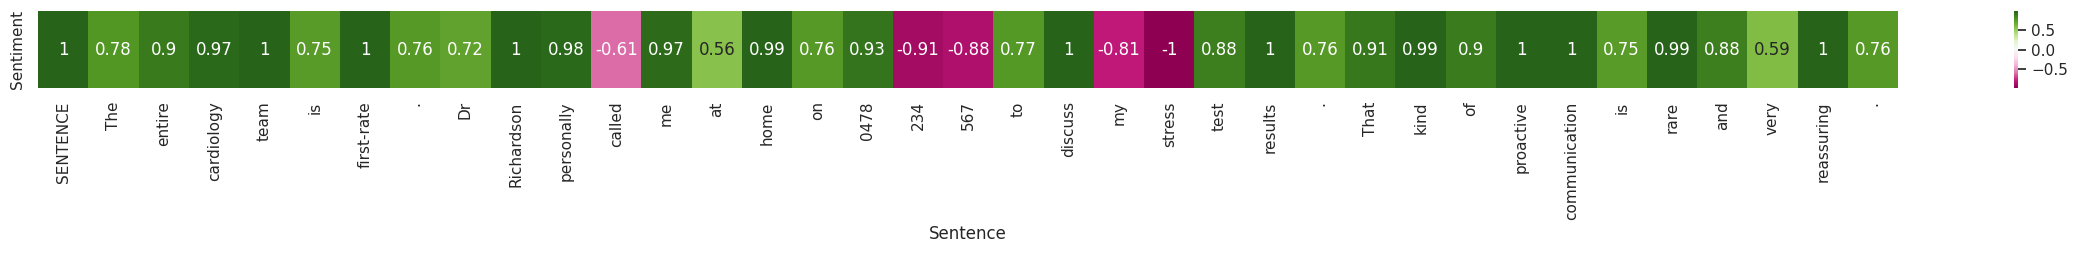

In [24]:
s = flair.data.Sentence(data[18])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})

['Sentence[57]: "The car park needs more disabled bays. I have a temporary mobility permit after my cardiac rehab and struggled to find a spot on 20 March 2026. My cardiologist at the Prince Charles Hospital, Dr Andrew Walsh, also coordinates with Dr Richardson here which gives me great confidence in my care plan."'/'POSITIVE' (0.9989)]


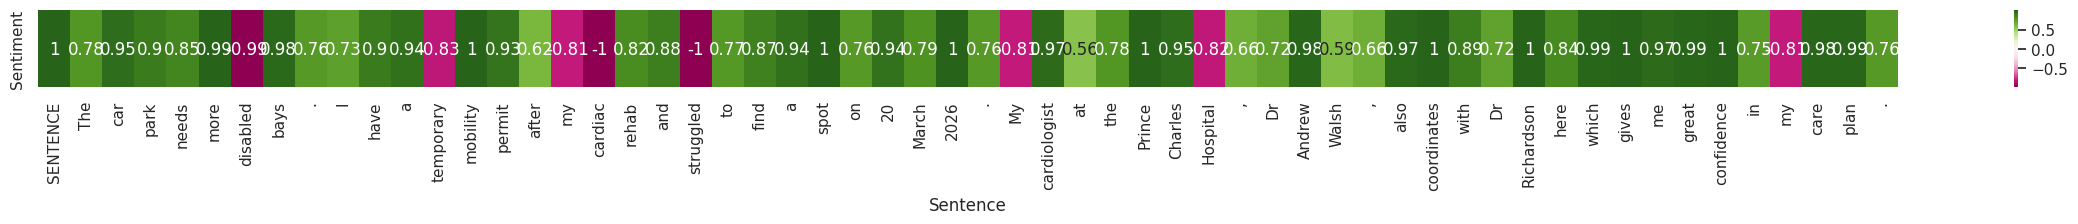

In [25]:
s = flair.data.Sentence(data[19])
flair_sentiment.predict(s)
total_sentiment = s.labels
print(total_sentiment)

tokens = [token.text for token in s.tokens]
ss = [flair.data.Sentence(s) for s in tokens]
[flair_sentiment.predict(s) for s in ss]
sentiments = [s.labels[0].score if s.labels[0].value == 'POSITIVE' else s.labels[0].score * -1 for s in ss]

visualise_sentiments({
      "Sentence":["SENTENCE"] + tokens,
      "Sentiment":[total_sentiment[0].score] + sentiments,
})